In [98]:
dataset_path=("/content/drive/MyDrive/ASSIGNMENT/weatherHistory.csv")

In [99]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import matplotlib.pyplot as plt
df = pd.read_csv(dataset_path)
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [100]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'],utc=True)
df[['Formatted Date']].head()

,Formatted Date
0,2006-03-31 22:00:00+00:00
1,2006-03-31 23:00:00+00:00
2,2006-04-01 00:00:00+00:00
3,2006-04-01 01:00:00+00:00
4,2006-04-01 02:00:00+00:00


In [101]:
daily_df=df.resample('D',on='Formatted Date').agg(
    {
        'Temperature (C)' : 'mean',
        'Humidity' : 'mean',
        'Wind Speed (km/h)' : 'mean'
    }
)

In [102]:
daily_df.head()

,Temperature (C),Humidity,Wind Speed (km/h)
Formatted Date,,,
2005-12-31 00:00:00+00:00,0.577778,0.890000,17.114300
2006-01-01 00:00:00+00:00,4.075000,0.817083,21.229192
2006-01-02 00:00:00+00:00,5.263194,0.847083,17.824713
2006-01-03 00:00:00+00:00,2.340509,0.897083,7.726658
2006-01-04 00:00:00+00:00,2.251852,0.906667,12.152817


In [103]:
daily_df.isnull().sum()

,0
Temperature (C),0
Humidity,0
Wind Speed (km/h),0


In [104]:
from sklearn.preprocessing import MinMaxScaler
features=daily_df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']]
train_size = int(len(features) * 0.7)
val_size = int(len(features) * 0.15)

train_features = features[:train_size]
val_features = features[train_size:train_size + val_size]
test_features = features[train_size + val_size:]

scaler = MinMaxScaler()

train_data = scaler.fit_transform(train_features)
val_data = scaler.transform(val_features)
test_data = scaler.transform(test_features)


In [105]:
print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

(2813, 3)
(602, 3)
(604, 3)


In [106]:
def create_sequences(data, sequence_length=7):
  x=[]
  y=[]
  for i in range(len(data)-sequence_length):
    x.append(data[i:i+sequence_length])
    y.append(data[i+sequence_length,0])
  return np.array(x), np.array(y)

In [107]:
X_train, y_train = create_sequences(train_data)

X_val, y_val = create_sequences(val_data)

X_test, y_test = create_sequences(test_data)

In [108]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(2806, 7, 3)
(2806,)
(595, 7, 3)
(595,)
(597, 7, 3)
(597,)


In [109]:
model = Sequential([
    SimpleRNN(32, input_shape=(7, 3)),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [110]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [111]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0256 - mae: 0.1160 - val_loss: 0.0057 - val_mae: 0.0594
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055 - mae: 0.0589 - val_loss: 0.0038 - val_mae: 0.0491
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - mae: 0.0503 - val_loss: 0.0029 - val_mae: 0.0423
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - mae: 0.0476 - val_loss: 0.0028 - val_mae: 0.0416
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0457 - val_loss: 0.0034 - val_mae: 0.0463
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0463 - val_loss: 0.0021 - val_mae: 0.0363
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - mae: 0.0422 - val_loss: 0.0023 - val_mae: 0.0376
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - mae: 0.0419 - val_loss: 0.0020 - val_mae: 0.0350
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - mae: 

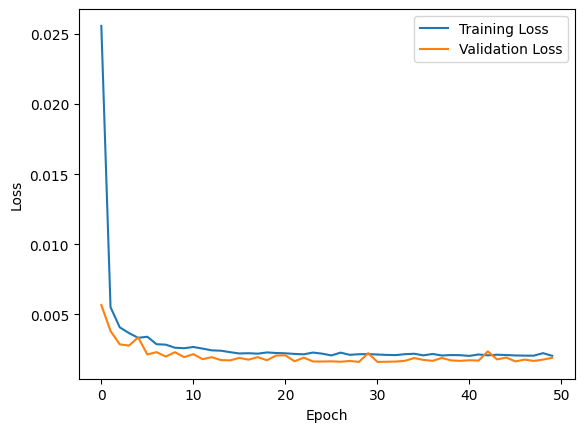

In [112]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [113]:
y_pred = model.predict(X_test)

print(y_pred.shape)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(597, 1)


In [114]:
y_pred_full = np.zeros((len(y_pred), 3))
y_pred_full[:, 0] = y_pred[:, 0]
y_pred_actual = scaler.inverse_transform(y_pred_full)[:, 0]
y_test_full = np.zeros((len(y_test), 3))
y_test_full[:, 0] = y_test

y_test_actual = scaler.inverse_transform(y_test_full)[:, 0]

In [115]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("RMSE:", rmse)

RMSE: 2.1244325724556714


In [116]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("MAE:", mae)

MAE: 1.6856259623568834


In [117]:
r2 = r2_score(y_test_actual, y_pred_actual)

print("R²:", r2)

R²: 0.9373402921896384


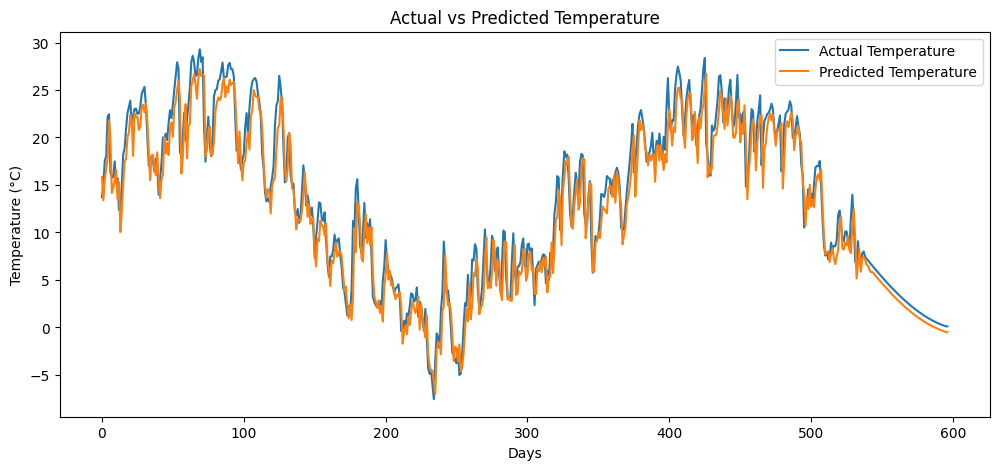

In [118]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_actual, label='Actual Temperature')
plt.plot(y_pred_actual, label='Predicted Temperature')

plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.title('Actual vs Predicted Temperature')
plt.legend()
plt.show()

In [119]:
last_sequence = test_data[-7:]
last_sequence = last_sequence.reshape(1, 7, 3)

future_predictions = []

for i in range(7):
    prediction = model.predict(last_sequence, verbose=0)

    future_predictions.append(prediction[0, 0])

    new_row = last_sequence[0, -1, :].copy()
    new_row[0] = prediction[0, 0]

    last_sequence = np.append(
        last_sequence[:, 1:, :],
        new_row.reshape(1, 1, 3),
        axis=1
    )

print(future_predictions)

[np.float32(0.33033705), np.float32(0.31586722), np.float32(0.30450338), np.float32(0.29496065), np.float32(0.28689724), np.float32(0.27987552), np.float32(0.27359965)]


In [120]:
future_predictions = np.array(future_predictions)

future_full = np.zeros((7, 3))
future_full[:, 0] = future_predictions

future_predictions_actual = scaler.inverse_transform(future_full)[:, 0]

print("Next 7 days predicted temperature:")
print(future_predictions_actual)

Next 7 days predicted temperature:
[-0.50789263 -1.18469224 -1.71621453 -2.16255822 -2.53970909 -2.86813728
 -3.16167913]


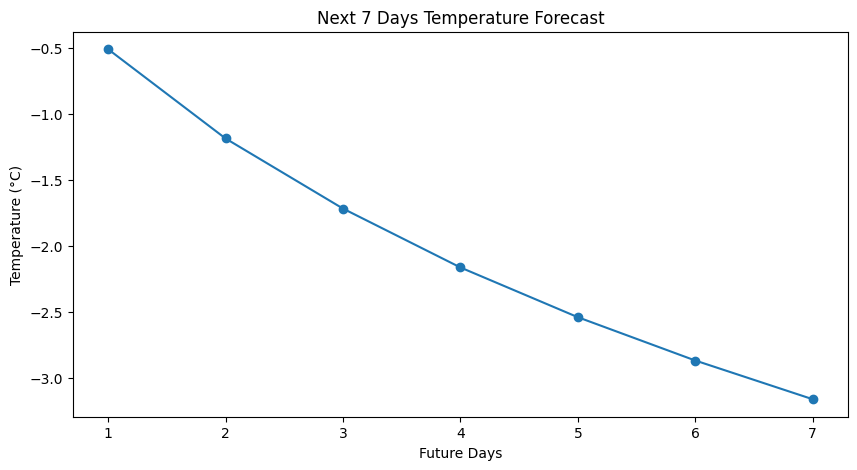

In [121]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, 8), future_predictions_actual, marker='o')

plt.xlabel('Future Days')
plt.ylabel('Temperature (°C)')
plt.title('Next 7 Days Temperature Forecast')

plt.xticks(range(1, 8))
plt.show()